In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [6]:
final_clean_strained = split_by_mouse(final_clean_strained)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["vx", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained, num_features, cat_features, log_features, minmax_features
)

In [7]:
final_clean_strained.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [8]:
final_clean_strained.groupby(["Subject"])["Noise"].unique()

Subject
WPZ100     [0.0]
WPZ101     [0.0]
WPZ102    [0.94]
WPZ103    [0.94]
WPZ104    [0.98]
           ...  
WPZ94      [0.9]
WPZ96      [0.9]
WPZ97      [0.9]
WPZ98      [0.9]
WPZ99      [0.0]
Name: Noise, Length: 105, dtype: object

In [9]:
cols = [
    "Amplitude",
    "Slope",
    "Distance",
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

reformatted = []

for col in cols:
    df = (
        final_clean_strained.pivot_table(
            index=["Subject", "Frequency"], columns="Level", values=col
        )
        .rename_axis(columns="Level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted.append(df)
reformatted = pd.concat(reformatted, axis=1)

# Add Noise column
noise = final_clean_strained.groupby(["Subject", "Frequency"])["Noise"].mean()
synapses = final_clean_strained.groupby(["Subject", "Frequency"])[
    "SynapsesPerIHC"
].mean()
groups = final_clean_strained.groupby(["Subject", "Frequency"])[
    ["DataGroup", "Strain_b"]
].first()

# Combine
reformatted = reformatted.join(noise).join(synapses).join(groups)

# fill NaNs with interpolated/extrapolated values:
for col in cols:
    amp_cols = [c for c in reformatted.columns if c.startswith(col)]
    reformatted[amp_cols] = reformatted[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )
reformatted.reset_index(inplace=True)
reformatted.head(10)

,Subject,Frequency,Amplitude_10.0,Amplitude_15.0,Amplitude_20.0,Amplitude_25.0,Amplitude_30.0,Amplitude_35.0,Amplitude_40.0,Amplitude_45.0,...,TroughIRightCurvature_55.0,TroughIRightCurvature_60.0,TroughIRightCurvature_65.0,TroughIRightCurvature_70.0,TroughIRightCurvature_75.0,TroughIRightCurvature_80.0,Noise,SynapsesPerIHC,DataGroup,Strain_b
0,WPZ100,8.0,0.077961,0.077961,0.029777,0.090885,0.137358,0.296385,0.381854,0.519497,...,14.796865,25.079451,13.892941,2.706432,1.739748,0.773064,0.00,15.892142,Test,1
1,WPZ100,11.3,0.050718,0.050718,0.000000,0.168245,0.302752,0.392846,0.477460,0.668926,...,6.280679,5.094698,2.653182,0.211666,0.260892,0.310118,0.00,16.492360,Test,1
2,WPZ100,16.0,0.059556,0.077295,0.047106,0.121329,0.202553,0.426837,0.424367,0.526245,...,3.128261,0.390464,0.450276,0.510088,0.333558,0.157028,0.00,17.564103,Test,1
3,WPZ100,22.6,0.063072,0.063072,0.060886,0.098964,0.223176,0.255710,0.359520,0.548261,...,3.570113,1.643706,0.862335,0.080963,0.440617,0.800270,0.00,17.381424,Test,1
4,WPZ100,32.0,0.091900,0.091900,0.257800,0.321347,0.333101,0.498574,0.664046,0.841320,...,0.821376,0.622318,2.515715,4.409113,2.254731,0.100350,0.00,18.314239,Test,1
5,WPZ100,45.2,0.079988,0.079988,0.064308,0.129407,0.054423,0.130737,0.151740,0.219944,...,6.313868,12.019363,6.413762,0.808162,0.566801,0.325440,0.00,17.846405,Test,1
6,WPZ101,32.0,0.054107,0.087369,0.057180,0.286407,0.411283,0.572701,0.734120,1.078561,...,11.750996,22.945029,13.590213,4.235397,42.735342,81.235287,0.00,16.193497,Train,1
7,WPZ101,45.2,0.043558,0.111223,0.131910,0.057465,0.140146,0.098869,0.097000,0.115595,...,18.925156,4.778665,10.090546,6.866563,17.967283,8.283850,0.00,15.351421,Train,1
8,WPZ102,8.0,0.067254,0.180315,0.126208,0.006525,0.139418,0.266449,0.441124,0.574855,...,4.034692,3.181216,14.842119,26.503023,13.575201,0.647380,0.94,14.334043,Train,1
9,WPZ102,11.3,0.195773,0.029398,0.095163,0.233439,0.310324,0.502138,0.693951,0.728227,...,3.145657,2.266414,1.203518,0.140623,0.097414,0.054206,0.94,16.569307,Train,1


In [10]:
reformatted["target"] = [0 if x else 1 for x in (reformatted["Noise"] == 0)]

# Lasso

In [11]:
num_features = []
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["Noise"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [12]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Lasso training set score: {pipeline.score(X_train, y_train)}")
print(f"Lasso test set score: {pipeline.score(X_test, y_test)}")

Lasso training set score: 0.09589935868589872
Lasso test set score: 0.11664135805600473


# Random Forest Regressor

In [13]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 25, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 15, 'rf__max_features': 'log2', 'rf__max_depth': 40}
Best RF score: 0.030, R2 on test set: 0.217


In [14]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([0, 1.1], [0, 1.1], "k--", alpha=0.5)
    plt.axis("square")
    plt.xlim(0, 1.1)
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.xlabel("GT Noise")
    plt.ylabel("Predicted Noise")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["Noise"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                1,
                0,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        1,
        0,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        1,
        0,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: -0.013, RMSE: 0.456
11.3Hz, 103 samples, R2: 0.127, RMSE: 0.421
16.0Hz, 103 samples, R2: 0.214, RMSE: 0.399
22.6Hz, 103 samples, R2: 0.382, RMSE: 0.354
32.0Hz, 105 samples, R2: 0.375, RMSE: 0.356
45.2Hz, 100 samples, R2: 0.194, RMSE: 0.404
All data, 616 samples, R2: 0.217, RMSE: 0.399


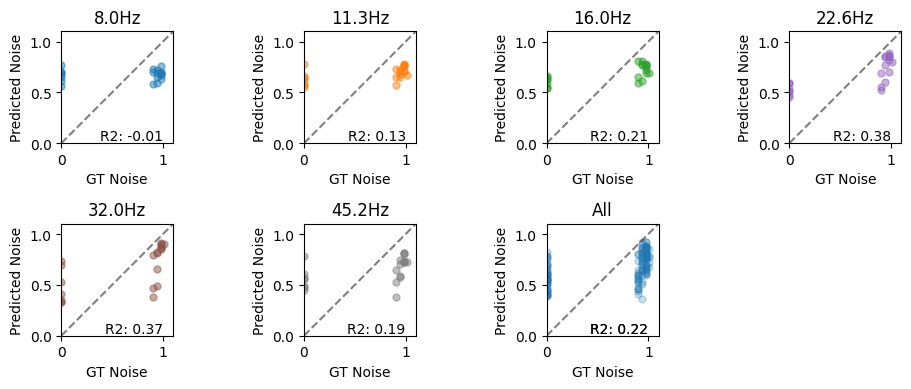

In [15]:
train_plot_result_frequency(reformatted, best_rf_model)

# Logistic Regression

In [16]:
num_features = []
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
# y = LabelEncoder().fit_transform(reformatted["Noise"])
y = reformatted["target"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [17]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.7494908350305499
Logistic regression test set accuracy: 0.712


# Random Forest

In [18]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 15, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.707, R2 on test set: 0.720


In [19]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["target"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            f1 = f1_score(y_test1, preds)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}, F1: {f1:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    f1 = f1_score(y_test, preds)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}, F1: {f1:.3f}")
    print(classification_report(y_test, preds))

In [20]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.700, F1: 0.812
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.68      1.00      0.81        13

    accuracy                           0.70        20
   macro avg       0.84      0.57      0.53        20
weighted avg       0.79      0.70      0.62        20

11.3Hz, 103 samples, Acc: 0.667, F1: 0.800
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.67      1.00      0.80        14

    accuracy                           0.67        21
   macro avg       0.33      0.50      0.40        21
weighted avg       0.44      0.67      0.53        21

16.0Hz, 103 samples, Acc: 0.667, F1: 0.800
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.67      1.00      0.80        14

    accuracy                           0.67        21


In [21]:
num_features = []
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = LabelEncoder().fit_transform(reformatted["Noise"])

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [22]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.384928716904277
Logistic regression test set accuracy: 0.424


In [23]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 50, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 5}
Best RF score: 0.350, R2 on test set: 0.384


In [24]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = LabelEncoder().fit_transform(data["Noise"])
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}")
    print(classification_report(y_test, preds))

In [25]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.350
              precision    recall  f1-score   support

           0       0.36      0.71      0.48         7
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         1
           5       0.20      0.33      0.25         3
           7       1.00      0.25      0.40         4
           8       0.00      0.00      0.00         2

    accuracy                           0.35        20
   macro avg       0.26      0.22      0.19        20
weighted avg       0.35      0.35      0.28        20

11.3Hz, 103 samples, Acc: 0.286
              precision    recall  f1-score   support

           0       0.38      0.86      0.52         7
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1
           6   

# Predicting Binary Noise Groups (<91dB vs. >= 91dB)

In [26]:
reformatted["Noise"].value_counts()

Noise
0.00    193
0.98    115
0.94    100
0.90     82
0.94     37
0.98     28
1.01     16
0.98     14
0.94     13
0.90      9
0.90      9
Name: count, dtype: int64

In [27]:
num_features = []
cat_features = ["Strain_b"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

reformatted["target_90"] = [0 if x else 1 for x in (reformatted["Noise"] <= 0.91)]
X = reformatted[num_features + cat_features + log_features]
y = reformatted["target_90"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [28]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.7535641547861507
Logistic regression test set accuracy: 0.712


In [29]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 30, 'rf__max_features': 'log2', 'rf__max_depth': 40}
Best RF score: 0.615, R2 on test set: 0.784


In [30]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["target_90"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}")
    print(classification_report(y_test, preds))

In [31]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.500
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20

11.3Hz, 103 samples, Acc: 0.524
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.52      1.00      0.69        11

    accuracy                           0.52        21
   macro avg       0.26      0.50      0.34        21
weighted avg       0.27      0.52      0.36        21

16.0Hz, 103 samples, Acc: 0.524
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.52      1.00      0.69        11

    accuracy                           0.52        21
   macro avg       0.26      0.50

In [32]:
X = reformatted[num_features + cat_features + log_features]
rf_pipeline.fit(X_train, y_train)
reformatted["noise_preds"] = rf_pipeline.predict(X)

In [33]:
reformatted["noise_proba"] = rf_pipeline.predict_proba(X)[:, 1]

In [34]:
preds = reformatted.groupby(["Subject"]).agg({"noise_proba": "mean"})
preds["noise_proba"] = np.where(preds > 0.5, 1, 0)
preds

,noise_proba
Subject,
WPZ100,0
WPZ101,0
WPZ102,1
WPZ103,1
WPZ104,1
...,...
WPZ94,0
WPZ96,0
WPZ97,0


In [35]:
(
    preds.values == reformatted.groupby(["Subject"]).agg({"target_90": "first"}).values
).sum() / len(preds)

0.9714285714285714

In [36]:
reformatted.groupby(["Subject"]).agg({"target_90": "first"})

,target_90
Subject,
WPZ100,0
WPZ101,0
WPZ102,1
WPZ103,1
WPZ104,1
...,...
WPZ94,0
WPZ96,0
WPZ97,0


In [37]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV


def make_comparison_plot(name, X_train, y_train, X_test, y_test, clf):
    fig, ax = plt.subplots(figsize=(7, 6))
    preds = clf.predict_proba(X_test)[:, 1]
    CalibrationDisplay.from_predictions(
        y_test, preds, n_bins=10, ax=ax, name="Uncalibrated"
    )
    cal_clf = CalibratedClassifierCV(clf, method=name, n_jobs=-1)
    cal_clf.fit(X_train, y_train)
    cal_preds = cal_clf.predict_proba(X_test)[:, 1]
    CalibrationDisplay.from_predictions(
        y_test, cal_preds, n_bins=10, ax=ax, name="Calibrated"
    )
    plt.title(f"Uncalibrated probabilities vs. calibrated probabilities ({name})")
    plt.show()

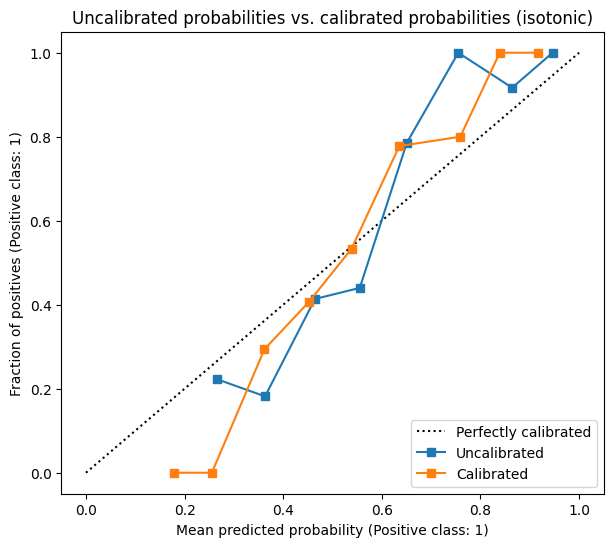

In [38]:
make_comparison_plot("isotonic", X_train, y_train, X_test, y_test, rf_pipeline)

In [39]:
cal_clf = CalibratedClassifierCV(rf_pipeline, method="isotonic", n_jobs=-1)
cal_clf.fit(X_train, y_train)
reformatted["calibrated_proba"] = cal_clf.predict_proba(X)[:, 1]

In [40]:
preds = reformatted.groupby(["Subject"]).agg({"calibrated_proba": "mean"})
preds["noise_proba"] = np.where(preds > 0.5, 1, 0)
preds_dict = preds["noise_proba"].to_dict()
reformatted["noise_preds"] = reformatted["Subject"].replace(preds_dict)

In [41]:
(
    preds.values == reformatted.groupby(["Subject"]).agg({"target_90": "first"}).values
).sum() / len(preds)

0.9714285714285714

In [42]:
(reformatted["noise_preds"] == reformatted["target_90"]).mean()

0.9707792207792207

In [60]:
num_features = []
cat_features = ["noise_preds"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [61]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.334, R2 on test set: 0.571


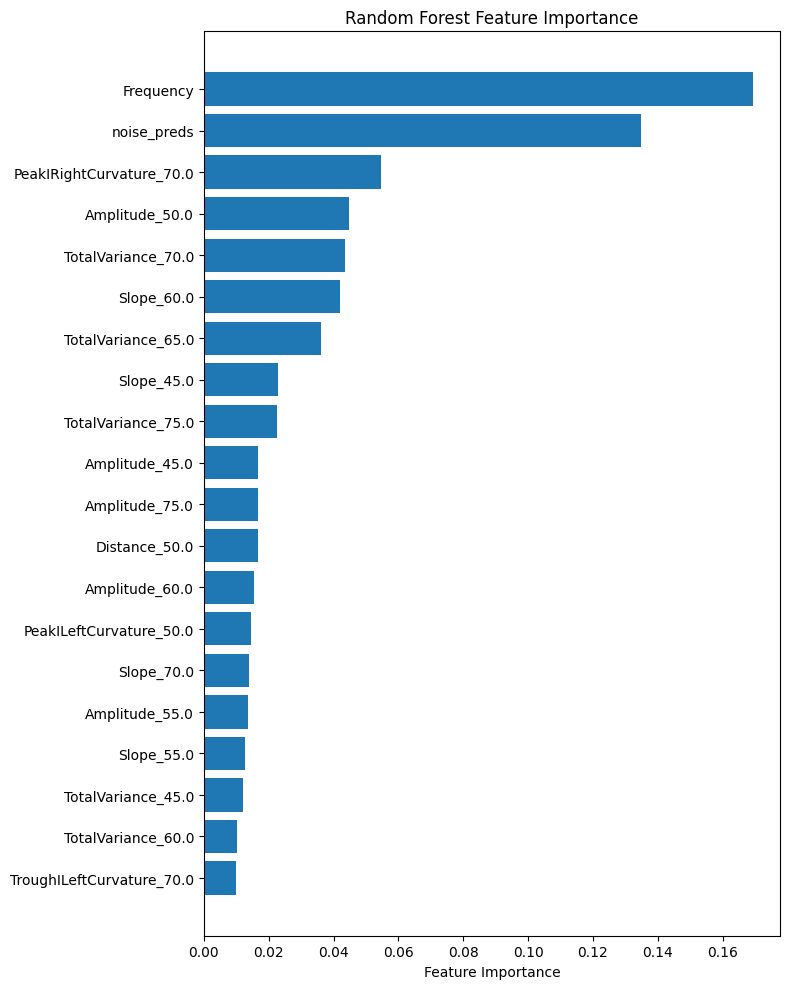

In [62]:
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(range(20), importance_df["Importance"][:20])
plt.yticks(range(20), importance_df["Feature"][:20])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [63]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: 0.095, RMSE: 0.965
11.3Hz, 103 samples, R2: 0.054, RMSE: 1.096
16.0Hz, 103 samples, R2: -0.101, RMSE: 1.329
22.6Hz, 103 samples, R2: 0.715, RMSE: 2.197
32.0Hz, 105 samples, R2: 0.466, RMSE: 3.308
45.2Hz, 100 samples, R2: 0.560, RMSE: 3.045
All data, 616 samples, R2: 0.571, RMSE: 2.306


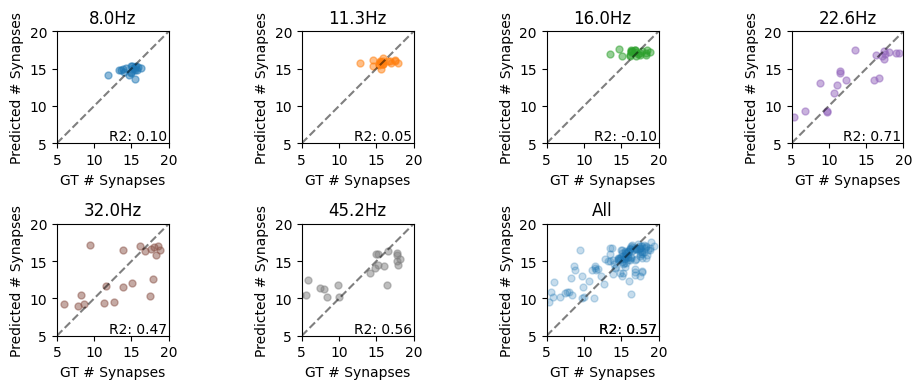

In [64]:
train_plot_result_frequency(reformatted, best_rf_model)

In [65]:
num_features = []
cat_features = ["noise_preds"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [66]:
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 500],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best RF params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best RF score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = clf_search.best_estimator_

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 25}
Best RF score: 0.341, R2 on test set: 0.553


8.0Hz, 102 samples, R2: -0.380, RMSE: 1.191
11.3Hz, 103 samples, R2: -0.176, RMSE: 1.222
16.0Hz, 103 samples, R2: -0.146, RMSE: 1.356
22.6Hz, 103 samples, R2: 0.698, RMSE: 2.261
32.0Hz, 105 samples, R2: 0.494, RMSE: 3.221
45.2Hz, 100 samples, R2: 0.658, RMSE: 2.683
All data, 616 samples, R2: 0.553, RMSE: 2.354


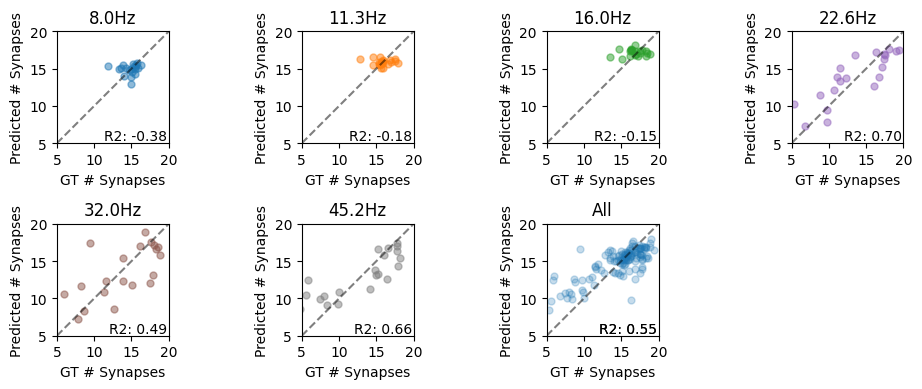

In [67]:
train_plot_result_frequency(reformatted, best_rf_model)